>dataset source: https://www.kaggle.com/datasets/shivamb/netflix-shows 


### 0- Questions / Goals

The objectives of this project:
- Which years had the most movies/TV shows added to Netflix?
- Which topics have the most content added by genre?
- How is the content distributed across countries?



In [46]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns 
import datetime

%matplotlib inline
%reload_ext autoreload
%autoreload 2

#   set seed for reproducibility
np.random.seed(0) 

In [47]:
netflix_data= pd.read_csv(r"C:\Users\musta\OneDrive\Desktop\Mini projeler\netflix_titles.csv")

### 1-Exploratory Data Analysis - EDA

Let's take a look at the first and last few lines.

In [48]:
netflix_data.head()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,Kirsten Johnson,NaN,United States,"September 25, 2021",2020,PG-13,90 min,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,NaN,"Ama Qamata, Khosi Ngema, Gail Mabalane, Thaban...",South Africa,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,Julien Leclercq,"Sami Bouajila, Tracy Gotoas, Samuel Jouy, Nabi...",NaN,"September 24, 2021",2021,TV-MA,1 Season,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,NaN,NaN,NaN,"September 24, 2021",2021,TV-MA,1 Season,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,NaN,"Mayur More, Jitendra Kumar, Ranjan Raj, Alam K...",India,"September 24, 2021",2021,TV-MA,2 Seasons,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [49]:
netflix_data.tail()

,show_id,type,title,director,cast,country,date_added,release_year,rating,duration,listed_in,description
8802,s8803,Movie,Zodiac,David Fincher,"Mark Ruffalo, Jake Gyllenhaal, Robert Downey J...",United States,"November 20, 2019",2007,R,158 min,"Cult Movies, Dramas, Thrillers","A political cartoonist, a crime reporter and a..."
8803,s8804,TV Show,Zombie Dumb,NaN,NaN,NaN,"July 1, 2019",2018,TV-Y7,2 Seasons,"Kids' TV, Korean TV Shows, TV Comedies","While living alone in a spooky town, a young g..."
8804,s8805,Movie,Zombieland,Ruben Fleischer,"Jesse Eisenberg, Woody Harrelson, Emma Stone, ...",United States,"November 1, 2019",2009,R,88 min,"Comedies, Horror Movies",Looking to survive in a world taken over by zo...
8805,s8806,Movie,Zoom,Peter Hewitt,"Tim Allen, Courteney Cox, Chevy Chase, Kate Ma...",United States,"January 11, 2020",2006,PG,88 min,"Children & Family Movies, Comedies","Dragged from civilian life, a former superhero..."
8806,s8807,Movie,Zubaan,Mozez Singh,"Vicky Kaushal, Sarah-Jane Dias, Raaghav Chanan...",India,"March 2, 2019",2015,TV-14,111 min,"Dramas, International Movies, Music & Musicals",A scrappy but poor boy worms his way into a ty...


Now we need to check the data types and missing value conditions.

In [50]:
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 8807 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8807 non-null   object
 1   type          8807 non-null   object
 2   title         8807 non-null   object
 3   director      6173 non-null   object
 4   cast          7982 non-null   object
 5   country       7976 non-null   object
 6   date_added    8797 non-null   object
 7   release_year  8807 non-null   int64 
 8   rating        8803 non-null   object
 9   duration      8804 non-null   object
 10  listed_in     8807 non-null   object
 11  description   8807 non-null   object
dtypes: int64(1), object(11)
memory usage: 825.8+ KB


>According to this, the “date_added” and “duration” columns have been assigned incorrect data types. We should convert the “date_added” column to the datetime type and the “duration” column to the ‘string’ type for series and the “int64” type for movies.

In [51]:
netflix_data.isnull().sum()

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

>As we can see, there are missing values in the “director, cast, country, date_added, rating, duration” columns.

In [52]:
#    Let's take a look at the basic statistics as well.
#   This makes it easier for us to check for outliers.

netflix_data.describe()

,release_year
count,8807.000000
mean,2014.180198
std,8.819312
min,1925.000000
25%,2013.000000
50%,2017.000000
75%,2019.000000
max,2021.000000


### 2- Data Cleaning

First, let's review the missing data again and assign it to a variable for later use.

In [53]:
missing_values_count= netflix_data.isnull().sum() # -> With this code, we can see how many NaN values there are in each row.

missing_values_count[0:10] # -> To find the NaN values in the first ten columns, this line of code can be used.


show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
dtype: int64

Now we need to find the total number of missing values.

In [54]:
total_cells= np.prod(netflix_data.shape)
total_missing= missing_values_count.sum()

In [55]:
#   Now we need to find out what percentage of the data is missing.

percent_missing= (total_missing/ total_cells)*100 
print(f"The missing data is equal to {percent_missing} of all data.")

The missing data is equal to 4.075356723818175 of all data.


In [56]:
#   look at the number of missing values in the twelve columns
missing_values_count[0:12]

show_id            0
type               0
title              0
director        2634
cast             825
country          831
date_added        10
release_year       0
rating             4
duration           3
listed_in          0
description        0
dtype: int64

In [57]:
#   Let's delete all columns containing at least one missing value.

na_dropped_clmn= netflix_data.dropna(axis=1)
na_dropped_clmn.head()

,show_id,type,title,release_year,listed_in,description
0,s1,Movie,Dick Johnson Is Dead,2020,Documentaries,"As her father nears the end of his life, filmm..."
1,s2,TV Show,Blood & Water,2021,"International TV Shows, TV Dramas, TV Mysteries","After crossing paths at a party, a Cape Town t..."
2,s3,TV Show,Ganglands,2021,"Crime TV Shows, International TV Shows, TV Act...",To protect his family from a powerful drug lor...
3,s4,TV Show,Jailbirds New Orleans,2021,"Docuseries, Reality TV","Feuds, flirtations and toilet talk go down amo..."
4,s5,TV Show,Kota Factory,2021,"International TV Shows, Romantic TV Shows, TV ...",In a city of coaching centers known to train I...


In [58]:
#   just how much data did we lose?
print("Columns in original dataset: %d \n" % netflix_data.shape[1])
print("Columns with na's dropped: %d" % na_dropped_clmn.shape[1])

Columns in original dataset: 12 

Columns with na's dropped: 6


So we've lost half of the columns from the beginning.

Before filling in the missing values in the data set, let's look at the ratios and decide accordingly.

- If it's ≤ 5%, we can discard it.
- If it's > 5%, we can fill it.
- If it's 30%, we may need to consider whether to use that column or not.

In [59]:
netflix_data.isnull().mean()*100

show_id          0.000000
type             0.000000
title            0.000000
director        29.908028
cast             9.367549
country          9.435676
date_added       0.113546
release_year     0.000000
rating           0.045418
duration         0.034064
listed_in        0.000000
description      0.000000
dtype: float64

In [60]:
#   Since there is a 29.9% rate of missing data in the Director column, these values have been filled with the “Unknown” category to maintain data integrity.
#   Records in columns with less than 1% missing values have been removed from the dataset.


#   Very few low-ratio categories
netflix_data = netflix_data[netflix_data["rating"].notna()]
netflix_data = netflix_data[netflix_data["date_added"].notna()]
netflix_data = netflix_data[netflix_data["duration"].notna()]



#   High-deficit categories
netflix_data["country"]= netflix_data["country"].fillna("Unknown")
netflix_data["cast"]= netflix_data["cast"].fillna("Unknown")
netflix_data["director"]= netflix_data["director"].fillna("Unknown")

>Note: If I had filled the “country” column using the “mode” command, some countries would have been disproportionately inflated in terms of percentage, and the distribution among countries would have been distorted. This would have become a disadvantage in the analysis.

In [61]:
netflix_data.shape

(8790, 12)

In [62]:
netflix_data["director"].value_counts().head()



director
Unknown                   2621
Rajiv Chilaka               19
Raúl Campos, Jan Suter      18
Suhas Kadav                 16
Marcus Raboy                16
Name: count, dtype: int64

In [63]:
netflix_data["cast"].value_counts().head()

cast
Unknown                                                                                    825
David Attenborough                                                                          19
Vatsal Dubey, Julie Tejwani, Rupa Bhimani, Jigna Bhardwaj, Rajesh Kava, Mousam, Swapnil     14
Samuel West                                                                                 10
Jeff Dunham                                                                                  7
Name: count, dtype: int64

In [64]:
netflix_data["country"].value_counts().head()

country
United States     2809
India              972
Unknown            829
United Kingdom     418
Japan              243
Name: count, dtype: int64

In [65]:
netflix_data.isnull().sum()

show_id         0
type            0
title           0
director        0
cast            0
country         0
date_added      0
release_year    0
rating          0
duration        0
listed_in       0
description     0
dtype: int64

Yes, we've now completed the basic cleaning phase.


 Now we need to find the data type of the “date_added” column and convert it to the “datetime” data type if it's incorrect.

In [66]:
netflix_data.info()

<class 'pandas.core.frame.DataFrame'>
Index: 8790 entries, 0 to 8806
Data columns (total 12 columns):
 #   Column        Non-Null Count  Dtype 
---  ------        --------------  ----- 
 0   show_id       8790 non-null   object
 1   type          8790 non-null   object
 2   title         8790 non-null   object
 3   director      8790 non-null   object
 4   cast          8790 non-null   object
 5   country       8790 non-null   object
 6   date_added    8790 non-null   object
 7   release_year  8790 non-null   int64 
 8   rating        8790 non-null   object
 9   duration      8790 non-null   object
 10  listed_in     8790 non-null   object
 11  description   8790 non-null   object
dtypes: int64(1), object(11)
memory usage: 892.7+ KB


As we can see, the Dtype of the “date_added” column is recorded as “Object.” So, as I mentioned, it is incorrect.


We need to change the type of this column to “datetime.”

In [67]:
#   create a new column, date_parsed, with the parsed dates

netflix_data["date_added"] = netflix_data["date_added"].str.strip()

netflix_data["date_parsed"] = pd.to_datetime(
    netflix_data["date_added"]
)

Now that we have set the correct Dtype, let's remove the duplicates as a final step.

In [68]:
netflix_data.drop_duplicates(inplace= True)

And the end of phase 2...

Our data is now ready for EDA 

### 3-Data Analysis

#### Question 1:

- Which years had the most movies/TV series added to Netflix?

In [69]:
netflix_data.groupby(netflix_data["date_parsed"].dt.year)["title"].count().sort_values(ascending=False)

date_parsed
2019    2016
2020    1879
2018    1648
2021    1498
2017    1185
2016     426
2015      82
2014      24
2011      13
2013      11
2012       3
2008       2
2009       2
2010       1
Name: title, dtype: int64



>As we can see, the highest number of content (films + series) uploaded to Netflix occurred in 2019 with 2016 pieces of content. In second place is 2020 with 1879 pieces of content, and in third place is 2018 with 1648 pieces of content.

What if we looked at these content types separately? Would we get different results if we made separate rankings for TV shows and movies? 

In [70]:
#   For TV Shows

netflix_data[netflix_data["type"] == "TV Show"] \
    .groupby(netflix_data["date_parsed"].dt.year)["title"] \
    .count() \
    .sort_values(ascending=False)

date_parsed
2020    595
2019    592
2021    505
2018    411
2017    349
2016    175
2015     26
2013      5
2014      5
2008      1
Name: title, dtype: int64

In [71]:
#   For Movies

netflix_data[netflix_data["type"]== "Movie"] \
    .groupby(netflix_data["date_parsed"].dt.year)["title"] \
        .count()  \
        .sort_values(ascending= False)

date_parsed
2019    1424
2020    1284
2018    1237
2021     993
2017     836
2016     251
2015      56
2014      19
2011      13
2013       6
2012       3
2009       2
2010       1
2008       1
Name: title, dtype: int64

Did you see? Some changes have occurred. 

---
- Ranking in TV Shows: 

> 1- 595 content with 2020

> 2- 592 content with 2019 

> 3- 505 content with 2021 


---


- Ranking for movies:

> 1- 1424 content with 2019

> 2- 1284 content with 2020 

> 3- 1237 content with 2018 

---

Now let's look at these data separately in graphs and interpret them.

- Pie chart:

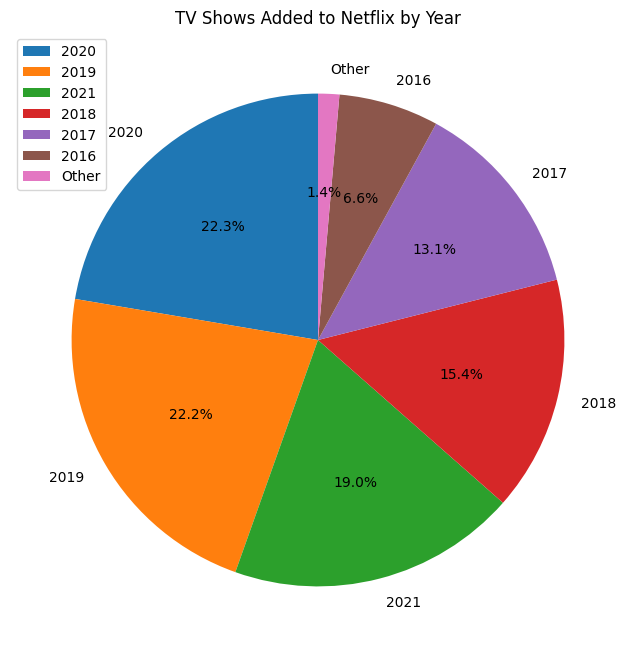

In [72]:
#   for TV Shows
y_pts = netflix_data[netflix_data["type"] == "TV Show"] \
    .groupby(netflix_data["date_parsed"].dt.year)["title"] \
    .count()

top_years = y_pts.sort_values(ascending=False).head(6)
other_sum = y_pts.sum() - top_years.sum()
top_years["Other"] = other_sum

plt.figure(figsize=(8,8))
plt.pie(top_years.values, labels=top_years.index, autopct='%1.1f%%', startangle=90)
plt.title("TV Shows Added to Netflix by Year")
plt.legend()
plt.show()

 As we can see, in terms of added TV Shows, the year 2020 covers the largest area with 22.3%.

  It is followed closely by 2019 with 22.2% and 2018 with 19.0%.
  
 2018 covers 15.4%, 2017 covers 13.1%, and 2016 covers 6.6%, while the remaining years account for only 1.4%.

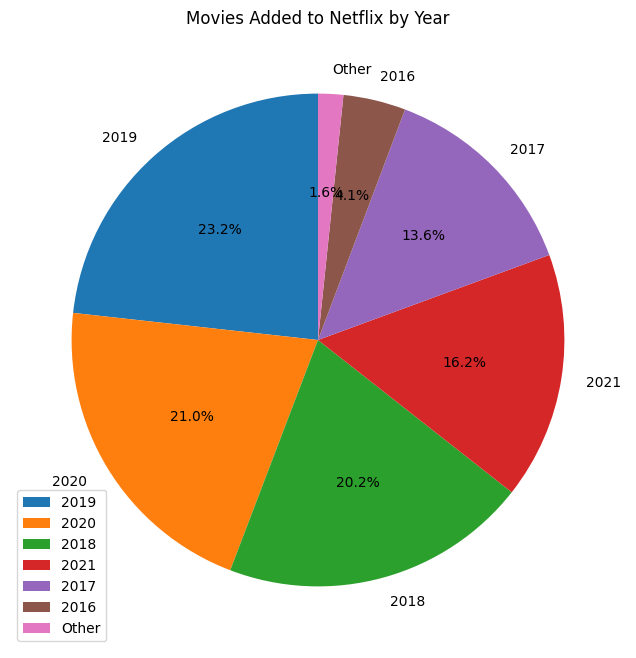

In [73]:
#   for Movies
y_pt = netflix_data[netflix_data["type"] == "Movie"] \
        .groupby(netflix_data["date_parsed"].dt.year)["title"] \
        .count()

topYears = y_pt.sort_values(ascending=False).head(6)
otherSum = y_pt.sum() - topYears.sum()

labels = list(topYears.index) + ["Other"]
sizes = list(topYears.values) + [otherSum]

plt.figure(figsize=(8,8))
plt.pie(sizes, labels=labels, autopct='%1.1f%%', startangle=90)
plt.title("Movies Added to Netflix by Year")
plt.legend()
plt.show()

 For movies, 2019 takes the largest share with 23.3%.
 
 It is followed by 2020 with 21.0%, 2018 with 20.2%, 2021 with 16.2%, 2017 with 13.6%, and 2016 with 4.1%.
 
 The remaining years account for only 1.6% of the area.

- Bar chart:

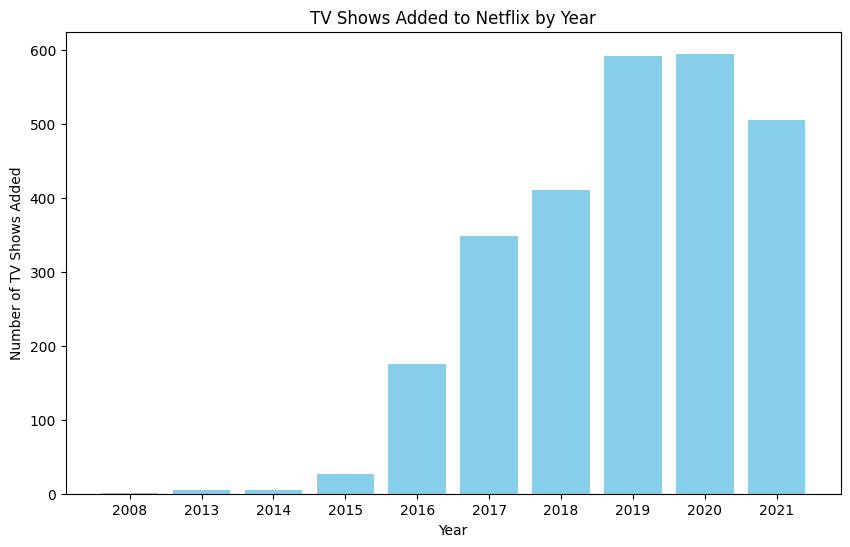

In [74]:
#   for TV Shows
y_pts
# x and y axes
x_pts = y_pts.index  # years
y_vals = y_pts.values  # number of TV Shows added each year

plt.figure(figsize=(10,6))
plt.bar(x_pts.astype(str), y_vals, color='skyblue')  # if we make x-axis string, the year labels will display properly
plt.xlabel("Year")
plt.ylabel("Number of TV Shows Added")
plt.title("TV Shows Added to Netflix by Year")
plt.show()

 By examining this chart, we can clearly see significant increases between 2008 and 2019.
 However, it is evident that the growth rate between 2019 and 2020 is quite low for some reasons.
 In fact, there is a noticeable decrease between 2020 and 2021.

 It can be estimated that the increase during 2019-2020 was influenced by the impact of Covid-19,
 and the decline in 2021 was due to the "normalization steps" taken in that year.

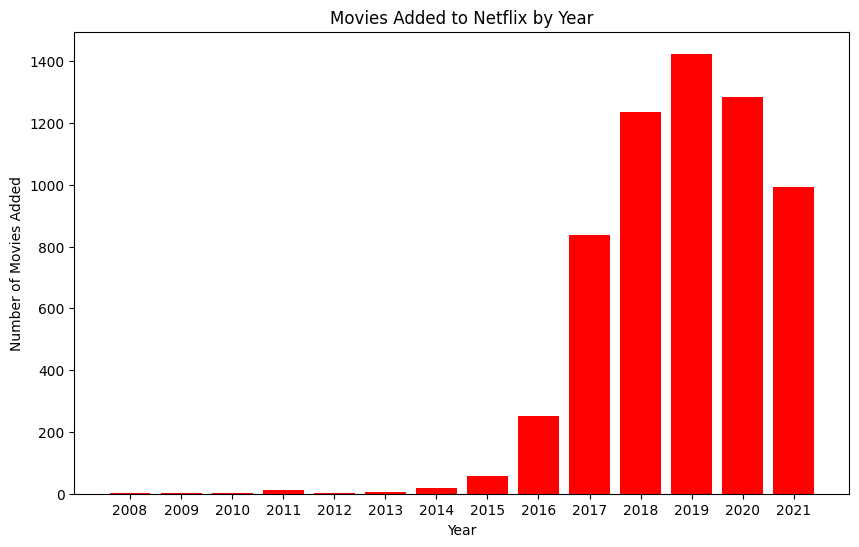

In [75]:
#   for Movies
y_pt
# x and y axes
x_pt = y_pt.index  # years
yVals = y_pt.values  # number of Movies each year

plt.figure(figsize=(10,6))
plt.bar(x_pt.astype(str), yVals, color='red')  # if we make x-axis string, the year labels will display properly
plt.xlabel("Year")
plt.ylabel("Number of Movies Added")
plt.title("Movies Added to Netflix by Year")
plt.show()

 The common feature between the TV Shows bar chart and the Movies bar chart is the noticeable increase between 2008 and 2019. However, the main difference is that the decline started in 2020 for Movies rather than in 2021 as it did for TV Shows. The remaining observations can also be considered for this chart.

- Comparison

Now let's view and interpret both data points on the same graph.

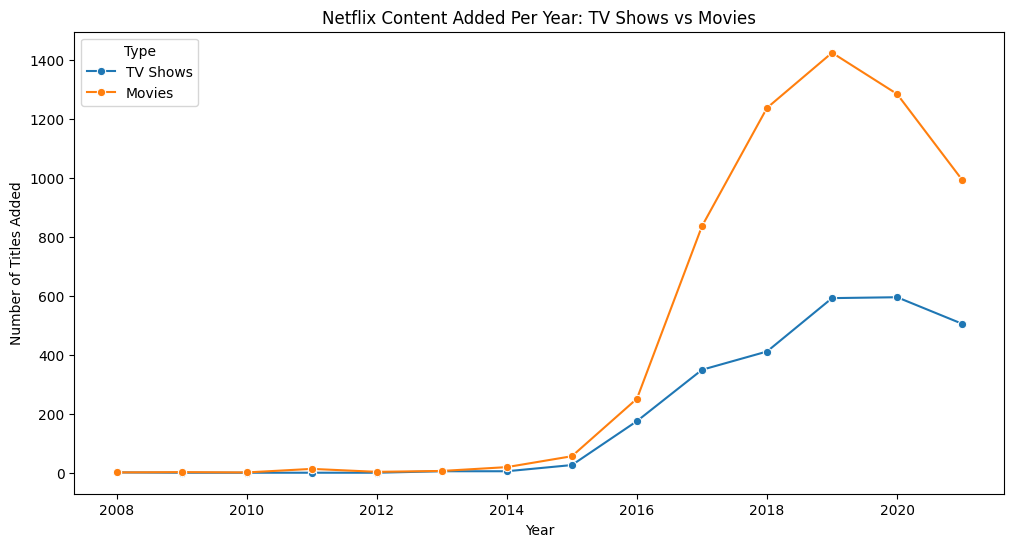

In [76]:
# Number of TV Shows
tv_by_year = netflix_data[netflix_data["type"] == "TV Show"] \
                .groupby(netflix_data["date_parsed"].dt.year)["title"].count()

# Number of Movies
movie_by_year = netflix_data[netflix_data["type"] == "Movie"] \
                .groupby(netflix_data["date_parsed"].dt.year)["title"].count()

# Create a Pandas DataFrame
df_compare = pd.DataFrame({
    "Year": tv_by_year.index.union(movie_by_year.index),  # all years
    "TV Shows": tv_by_year.reindex(tv_by_year.index.union(movie_by_year.index), fill_value=0).values,
    "Movies": movie_by_year.reindex(tv_by_year.index.union(movie_by_year.index), fill_value=0).values
})

# Convert to long format with melt (for Seaborn)
df_long = df_compare.melt(id_vars="Year", value_vars=["TV Shows", "Movies"], 
                          var_name="Type", value_name="Count")

plt.figure(figsize=(12,6))
sns.lineplot(data=df_long, x="Year", y="Count", hue="Type", marker="o")
plt.title("Netflix Content Added Per Year: TV Shows vs Movies")
plt.ylabel("Number of Titles Added")
plt.xlabel("Year")
plt.show()

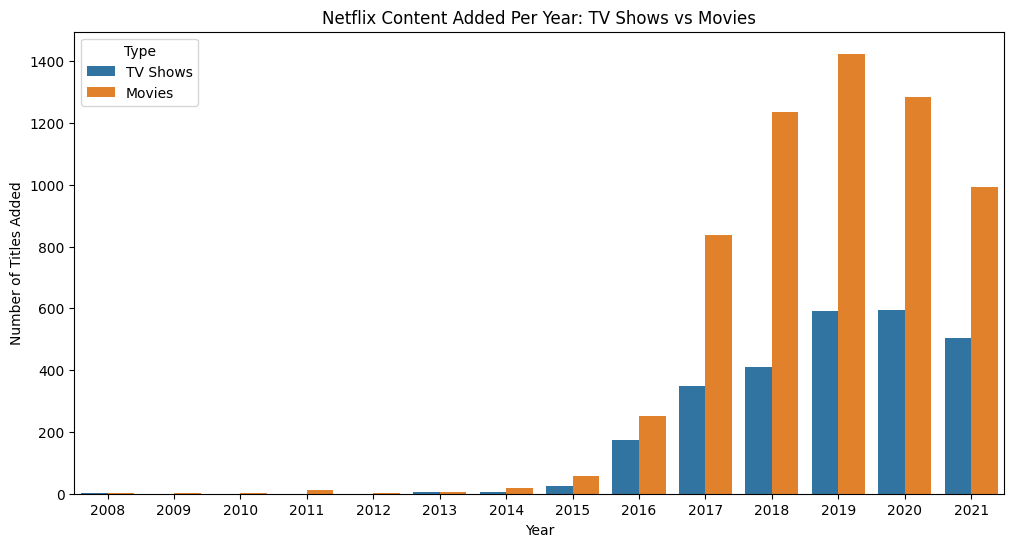

In [77]:
plt.figure(figsize=(12,6))
sns.barplot(data=df_long, x="Year", y="Count", hue="Type")
plt.title("Netflix Content Added Per Year: TV Shows vs Movies")
plt.ylabel("Number of Titles Added")
plt.xlabel("Year")
plt.show()

 As we can see, starting from 2016, both TV Shows and Movies increased, but the growth rate of Movies is much higher.

 - Hypothesis:
 > According to our observations, the increase in the number of films is faster than that of TV shows. This may be due to the production process for series being longer and more complex.

#### Question 2:

- Which topics have the most content added by genre?


First, let's check the data type of all genres

In [78]:
type(netflix_data["listed_in"].iloc[0])

str

 As we can see, it's of type string. We should convert it to a list so that we can access the genres more easily.

In [79]:
import re

In [80]:
#   The 'listed_in' column contains genres as a string separated by commas.
#   The code below first splits the values in the 'listed_in' column into a list by commas and optional spaces.
netflix_data["listed_in"] = netflix_data["listed_in"].str.split(r",\s*")  

#   Then, if there is more than one genre in a row, explode creates a separate row for each genre.
netflix_data_exploded = netflix_data.explode("listed_in")

#   Let's try it now
print(netflix_data_exploded[["title", "listed_in"]].head(10))

                   title               listed_in
0   Dick Johnson Is Dead           Documentaries
1          Blood & Water  International TV Shows
1          Blood & Water               TV Dramas
1          Blood & Water            TV Mysteries
2              Ganglands          Crime TV Shows
2              Ganglands  International TV Shows
2              Ganglands   TV Action & Adventure
3  Jailbirds New Orleans              Docuseries
3  Jailbirds New Orleans              Reality TV
4           Kota Factory  International TV Shows


Now our data is ready to answer the question.

In [81]:
netflix_data_exploded["listed_in"].value_counts()

listed_in
International Movies            2752
Dramas                          2426
Comedies                        1674
International TV Shows          1349
Documentaries                    869
Action & Adventure               859
TV Dramas                        762
Independent Movies               756
Children & Family Movies         641
Romantic Movies                  616
Thrillers                        577
TV Comedies                      573
Crime TV Shows                   469
Kids' TV                         448
Docuseries                       394
Music & Musicals                 375
Romantic TV Shows                370
Horror Movies                    357
Stand-Up Comedy                  343
Reality TV                       255
British TV Shows                 252
Sci-Fi & Fantasy                 243
Sports Movies                    219
Anime Series                     174
Spanish-Language TV Shows        173
TV Action & Adventure            167
Korean TV Shows             

 Accordingly, we can now list the most frequently added genre in the movie title:

 - 1-International Movies (2752 productions)
 - 2-Dramas (2426 productions)
 - 3-Comedies (1674 productions)

> So, if we examine film and TV series productions separately, will there be a change in the most added genres? Let's see.

In [82]:
netflix_data_exploded \
    .query("type == 'TV Show'")["listed_in"] \
    .value_counts()

listed_in
International TV Shows          1349
TV Dramas                        762
TV Comedies                      573
Crime TV Shows                   469
Kids' TV                         448
Docuseries                       394
Romantic TV Shows                370
Reality TV                       255
British TV Shows                 252
Anime Series                     174
Spanish-Language TV Shows        173
TV Action & Adventure            167
Korean TV Shows                  151
TV Mysteries                      98
Science & Nature TV               92
TV Sci-Fi & Fantasy               83
TV Horror                         75
Teen TV Shows                     69
TV Thrillers                      57
Stand-Up Comedy & Talk Shows      56
Classic & Cult TV                 26
TV Shows                          16
Name: count, dtype: int64

Ranking of the number of additions among TV programs:
- 1-International TV Shows (1349 productions)
- 2-TV Dramas (762 productions)
- 3-TV Comedies (573 productions)


In [87]:
netflix_data_exploded \
    .query("type == 'Movie'")["listed_in"] \
    .value_counts()

listed_in
International Movies        2752
Dramas                      2426
Comedies                    1674
Documentaries                869
Action & Adventure           859
Independent Movies           756
Children & Family Movies     641
Romantic Movies              616
Thrillers                    577
Music & Musicals             375
Horror Movies                357
Stand-Up Comedy              343
Sci-Fi & Fantasy             243
Sports Movies                219
Classic Movies               116
LGBTQ Movies                 102
Cult Movies                   71
Anime Features                71
Faith & Spirituality          65
Movies                        53
Name: count, dtype: int64

Ranking of the number of additions among Movies:
- 1- International Movies ( 2752 productions)
- 2- Dramas ( 2426 productions)
- 3- Comedies ( 1674 productions)

Now let's look at these data separately in graphs and interpret them.

- Pie Chart:

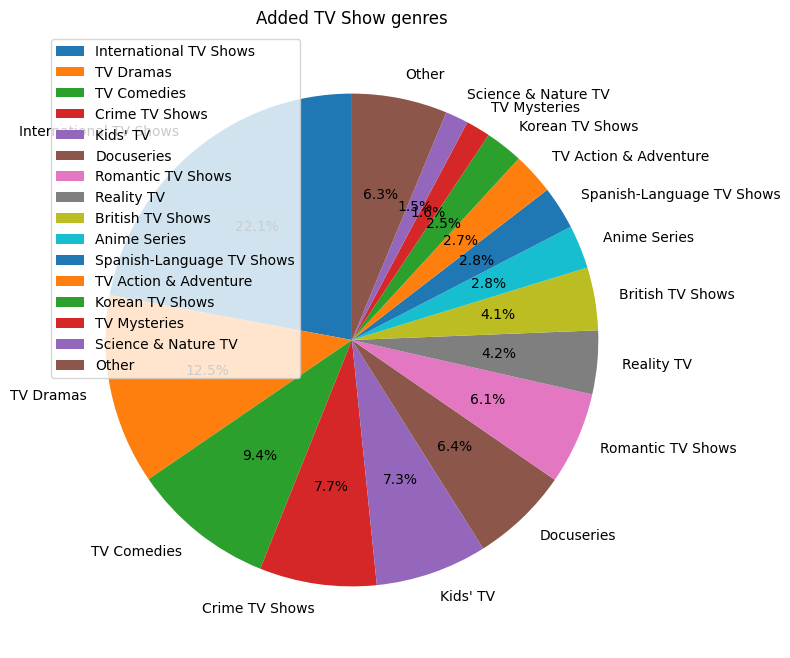

In [96]:
#   for TV Shows
y_pts = netflix_data_exploded \
        .query("type == 'TV Show'")["listed_in"] \
        .value_counts()
    

top_years = y_pts.sort_values(ascending=False).head(15)
other_sum = y_pts.sum() - top_years.sum()
top_years["Other"] = other_sum

plt.figure(figsize=(8,8))
plt.pie(top_years.values, labels=top_years.index, autopct='%1.1f%%', startangle=90)
plt.title("Added TV Show genres")
plt.legend()
plt.show()

 As we see on TV shows, the International TV Shows genre has the largest share at 22.1%.
 
 This is followed by TV Dramas at 12.5% and TV Comedies at 9.4%.
 
The remaining 6.3% of the market is divided among smaller genres, with Other accounting for 1.5%.

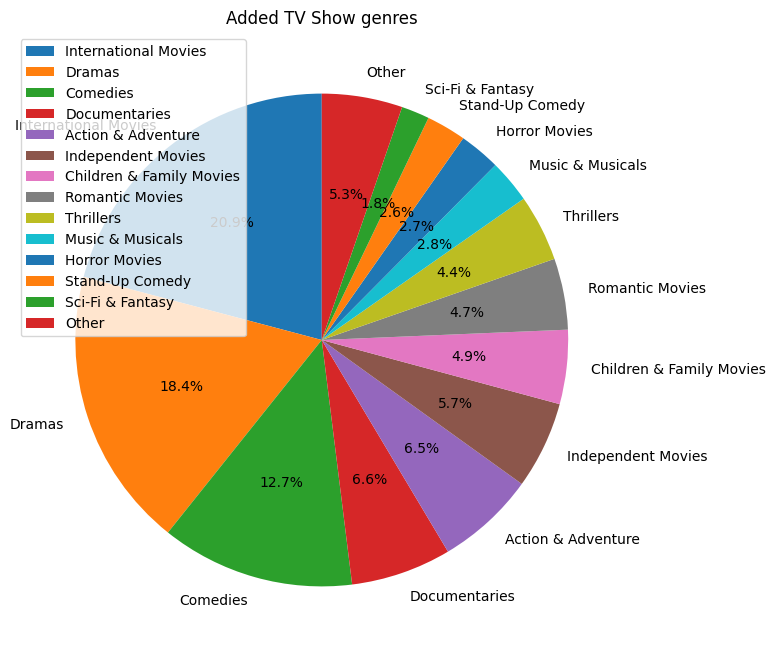

In [98]:
#   for Movies
y_pts = netflix_data_exploded \
        .query("type == 'Movie'")["listed_in"] \
        .value_counts()
    

top_years = y_pts.sort_values(ascending=False).head(13)
other_sum = y_pts.sum() - top_years.sum()
top_years["Other"] = other_sum

plt.figure(figsize=(8,8))
plt.pie(top_years.values, labels=top_years.index, autopct='%1.1f%%', startangle=90)
plt.title("Added TV Show genres")
plt.legend()
plt.show()

As we see in the films, the International Movies genre has the largest share at 20.9%.
 
 This is followed by Dramas at 18.4% and Comedies at 12.7%.
 
Only 5.3% of the market share goes to smaller genres, which account for 1.8% under the category “Other.”

- Bar Chart